In [1]:
import kagglehub
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
path = kagglehub.dataset_download("aljarah/xAPI-Edu-Data")
print("Dataset folder:", path)
print(os.listdir(path))

100%|██████████| 5.54k/5.54k [00:00<00:00, 7.90MB/s]

Extracting files...
Dataset folder: /root/.cache/kagglehub/datasets/aljarah/xAPI-Edu-Data/versions/6
['xAPI-Edu-Data.csv']


In [3]:
df = pd.read_csv(os.path.join(path, "xAPI-Edu-Data.csv"))

In [4]:
df.shape

(480, 17)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    480 non-null    object
 1   NationalITy               480 non-null    object
 2   PlaceofBirth              480 non-null    object
 3   StageID                   480 non-null    object
 4   GradeID                   480 non-null    object
 5   SectionID                 480 non-null    object
 6   Topic                     480 non-null    object
 7   Semester                  480 non-null    object
 8   Relation                  480 non-null    object
 9   raisedhands               480 non-null    int64 
 10  VisITedResources          480 non-null    int64 
 11  AnnouncementsView         480 non-null    int64 
 12  Discussion                480 non-null    int64 
 13  ParentAnsweringSurvey     480 non-null    object
 14  ParentschoolSatisfaction  

In [6]:
print(df.isnull().sum())


gender                      0
NationalITy                 0
PlaceofBirth                0
StageID                     0
GradeID                     0
SectionID                   0
Topic                       0
Semester                    0
Relation                    0
raisedhands                 0
VisITedResources            0
AnnouncementsView           0
Discussion                  0
ParentAnsweringSurvey       0
ParentschoolSatisfaction    0
StudentAbsenceDays          0
Class                       0
dtype: int64


In [7]:
print(df["Class"].value_counts())

Class
M    211
H    142
L    127
Name: count, dtype: int64


In [8]:
df["Class"].value_counts(normalize=True) * 100

,proportion
Class,
M,43.958333
H,29.583333
L,26.458333


In [9]:
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].unique())


gender:
['M' 'F']

NationalITy:
['KW' 'lebanon' 'Egypt' 'SaudiArabia' 'USA' 'Jordan' 'venzuela' 'Iran'
 'Tunis' 'Morocco' 'Syria' 'Palestine' 'Iraq' 'Lybia']

PlaceofBirth:
['KuwaIT' 'lebanon' 'Egypt' 'SaudiArabia' 'USA' 'Jordan' 'venzuela' 'Iran'
 'Tunis' 'Morocco' 'Syria' 'Iraq' 'Palestine' 'Lybia']

StageID:
['lowerlevel' 'MiddleSchool' 'HighSchool']

GradeID:
['G-04' 'G-07' 'G-08' 'G-06' 'G-05' 'G-09' 'G-12' 'G-11' 'G-10' 'G-02']

SectionID:
['A' 'B' 'C']

Topic:
['IT' 'Math' 'Arabic' 'Science' 'English' 'Quran' 'Spanish' 'French'
 'History' 'Biology' 'Chemistry' 'Geology']

Semester:
['F' 'S']

Relation:
['Father' 'Mum']

raisedhands:
[ 15  20  10  30  40  42  35  50  12  70  19   5  62  36  55  69  60   2
   0   8  25  75   4  45  14  33   7  13  29  39  49  16  28  27  21  80
  17  65  22  11   1   3 100   6  90  77  24  66  23  82  72  51  85  87
  95  81  53  92  83  67  96  57  73   9  32  52  59  61  79  18  74  97
  41  71  98  78  89  88  86  76  99  84]

VisITedResources

In [10]:
y = df["Class"]
X = df.drop("Class", axis=1)


In [11]:
print(X.columns)

Index(['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID',
       'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands',
       'VisITedResources', 'AnnouncementsView', 'Discussion',
       'ParentAnsweringSurvey', 'ParentschoolSatisfaction',
       'StudentAbsenceDays'],
      dtype='object')


In [12]:
print(y.head())

0    M
1    M
2    L
3    L
4    M
Name: Class, dtype: object


In [13]:
X_train,y_train,X_test,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


In [14]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

print("Categorical:", list(categorical_cols))
print("Numerical:", list(numerical_cols))

Categorical: ['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID', 'SectionID', 'Topic', 'Semester', 'Relation', 'ParentAnsweringSurvey', 'ParentschoolSatisfaction', 'StudentAbsenceDays']
Numerical: ['raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion']


In [15]:
print(X_train.shape)
print(X_test.shape)

(384, 16)
(384,)


In [16]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

In [17]:
X = df.drop("Class", axis=1)  # features
y = df["Class"]               # target

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print(X_train_encoded.shape)
print(X_test_encoded.shape)

(384, 72)
(96, 72)


In [22]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train_encoded, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [23]:
y_pred = model.predict(X_test_encoded)

In [24]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7708333333333334


In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           H       0.79      0.66      0.72        29
           L       0.88      0.84      0.86        25
           M       0.71      0.81      0.76        42

    accuracy                           0.77        96
   macro avg       0.79      0.77      0.78        96
weighted avg       0.78      0.77      0.77        96



In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           H       0.79      0.66      0.72        29
           L       0.88      0.84      0.86        25
           M       0.71      0.81      0.76        42

    accuracy                           0.77        96
   macro avg       0.79      0.77      0.78        96
weighted avg       0.78      0.77      0.77        96



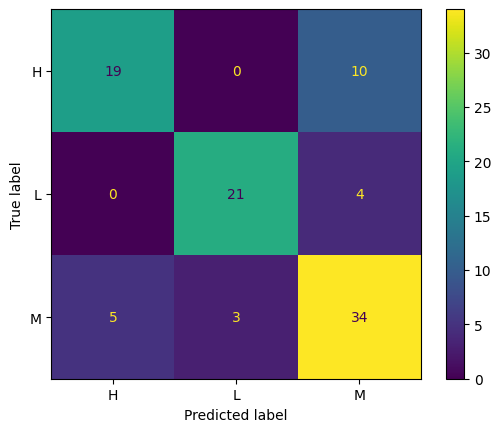

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.show()